In [1]:
from google.colab import files
import pandas as pd

# Upload CSV file
uploaded = files.upload()

# Read CSV into pandas DataFrame
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

# Show first 5 rows
df.head()


Saving iris.csv to iris.csv


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
# Dataset shape
print("Rows, Columns:", df.shape)

# Column names
print(df.columns)

# Data info (types, null values)
df.info()

# Summary statistics
df.describe()

# Check missing values
df.isnull().sum()


Rows, Columns: (891, 12)
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [4]:
# Mean, Median, Mode
print("Mean Age:", df['Age'].mean())
print("Median Fare:", df['Fare'].median())
print("Mode Embarked:", df['Embarked'].mode()[0])

# Count of survivors
print("Survivors count:\n", df['Survived'].value_counts())


Mean Age: 29.36158249158249
Median Fare: 14.4542
Mode Embarked: S
Survivors count:
 Survived
0    549
1    342
Name: count, dtype: int64


In [8]:
# Select numeric columns only
numeric_df = df.select_dtypes(include='number')

# Calculate correlation
correlation = numeric_df.corr()
print(correlation)


             PassengerId  Survived    Pclass       Age     SibSp     Parch  \
PassengerId     1.000000 -0.005007 -0.035144  0.034212 -0.057527 -0.001652   
Survived       -0.005007  1.000000 -0.338481 -0.064910 -0.035322  0.081629   
Pclass         -0.035144 -0.338481  1.000000 -0.339898  0.083081  0.018443   
Age             0.034212 -0.064910 -0.339898  1.000000 -0.233296 -0.172482   
SibSp          -0.057527 -0.035322  0.083081 -0.233296  1.000000  0.414838   
Parch          -0.001652  0.081629  0.018443 -0.172482  0.414838  1.000000   
Fare            0.012658  0.257307 -0.549500  0.096688  0.159651  0.216225   

                 Fare  
PassengerId  0.012658  
Survived     0.257307  
Pclass      -0.549500  
Age          0.096688  
SibSp        0.159651  
Parch        0.216225  
Fare         1.000000  


In [6]:
# Select numeric columns only
numeric_df = df.select_dtypes(include='number')

# Now calculate correlation
correlation = numeric_df.corr()
print(correlation)


             PassengerId  Survived    Pclass       Age     SibSp     Parch  \
PassengerId     1.000000 -0.005007 -0.035144  0.034212 -0.057527 -0.001652   
Survived       -0.005007  1.000000 -0.338481 -0.064910 -0.035322  0.081629   
Pclass         -0.035144 -0.338481  1.000000 -0.339898  0.083081  0.018443   
Age             0.034212 -0.064910 -0.339898  1.000000 -0.233296 -0.172482   
SibSp          -0.057527 -0.035322  0.083081 -0.233296  1.000000  0.414838   
Parch          -0.001652  0.081629  0.018443 -0.172482  0.414838  1.000000   
Fare            0.012658  0.257307 -0.549500  0.096688  0.159651  0.216225   

                 Fare  
PassengerId  0.012658  
Survived     0.257307  
Pclass      -0.549500  
Age          0.096688  
SibSp        0.159651  
Parch        0.216225  
Fare         1.000000  


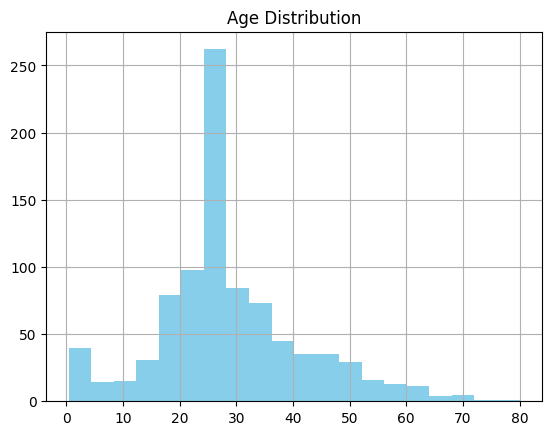

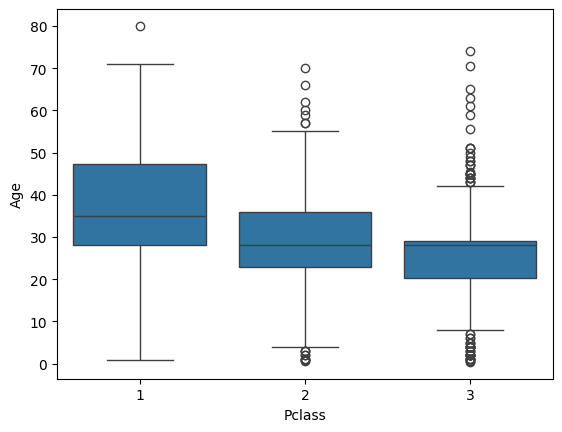

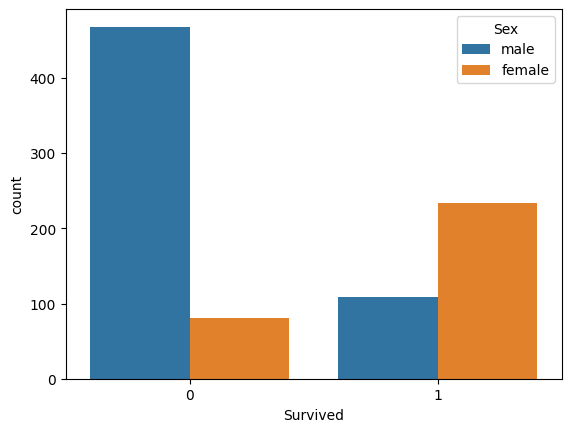

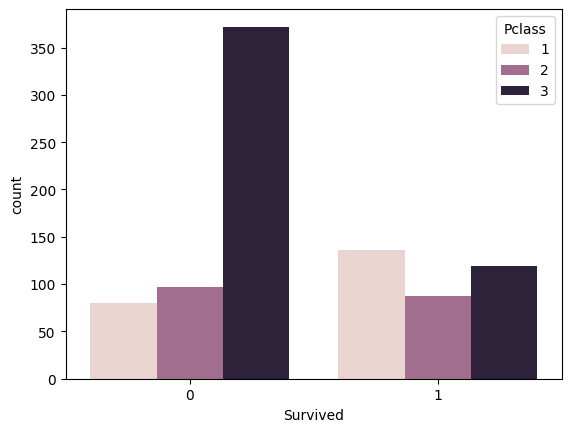

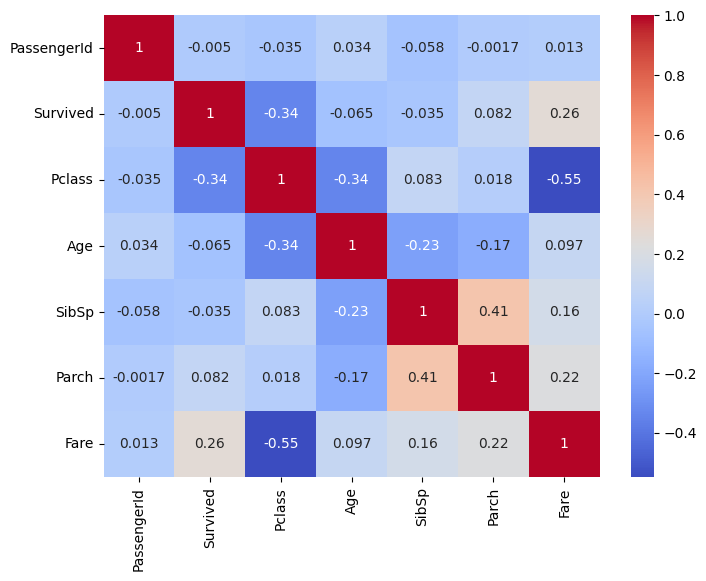

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram: Age distribution
df['Age'].hist(bins=20, color='skyblue')
plt.title("Age Distribution")
plt.show()

# Boxplot: Age by Pclass
sns.boxplot(x='Pclass', y='Age', data=df)
plt.show()

# Countplot: Survived by Sex
sns.countplot(x='Survived', hue='Sex', data=df)
plt.show()

# Countplot: Survived by Pclass
sns.countplot(x='Survived', hue='Pclass', data=df)
plt.show()

# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.show()


In [10]:
#group analysis
# Survival rate by Pclass
print(df.groupby('Pclass')['Survived'].mean())

# Survival rate by Sex
print(df.groupby('Sex')['Survived'].mean())


Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


In [11]:
df.to_csv('cleaned_titanic.csv', index=False)
files.download('cleaned_titanic.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>